# The College Town Bubble:  Housing prices and population changes over time in college towns compared to national averages.

## Possible Research Questions

This study examines US cities and their population growth rates and housing price changes over time. It compares similar metrics between cities with one or more colleges, and the dataset as a whole to see if there are any differences.

Potential questions to look into are: Do college towns grow at a faster or slower rate than other cities? Do college town housing prices experience less fluctuation than other cities? Are there differences amongst college towns? Do smaller college towns see different population and price trends than larger ones?

Another possible point of exploration is the change in housing prices compared to their patterns in pre and post COVID periods. Are prices in large cities going down? Are prices in small towns going up? Again, price trends can be examined under the lens of if a college presence can predict different behavior.

---

In [8]:
## load libraries
import pandas as pd
import numpy as np

## For Scraping
import requests # package for http requests
import bs4 # package for html parsing

## Foe Visualizing
import matplotlib.pyplot as plt

---

## Datasets and Data Cleanup

### State Name and Abbreviations

State names, and state abbreviation codes, were grabbed from Github (https://raw.githubusercontent.com/jasonong/List-of-US-States/master/states.csv). Some datasets used in this study used full state names in their data, while others used abbreviations—this dataset helped normalize the data.

In [9]:
# Import state names and abbreviations
state_codes = pd.read_csv("state_codes.csv")

---

### Zillow Housing Price Data
Zillow provides time-series data of house sale prices in the United States at (https://www.zillow.com/research/data/).

~~This is using their "ZHVI All homes (SFR, Condo/Co-op) Time Series, Smoothed Seasonally Adjusted($)" Dataset for US Cities.~~

This is using their "ZHVI Single Family Homes Time Series($)" Dataset for US Cities.

#### Data Cleanup
A preliminary attempt to merge the Zillow dataset with a list of college towns dataset produced numerous (83) unmatched entries. A frequent mismatch appears to be the inclusion of "Town of ..." or "Town of ...", as in "Town Of Ithaca" and "Town of Oswego", in the Zillow data. This was programmatically removed.

In addition, several columns were dropped or renamed for consistency with other datasets, and a new column was created which contains both city and state to facility filtering across multiple datasets.

In [10]:
# Helper Function

# Returns a string with all substrings in a list removed from it
def remove_all(list, str):
    for substr in list:
        index = 0
        length = len(substr)
        while str.find(substr) != -1:
            index = str.find(substr)
            str = str[0:index] + str[index+length:]
    return str

# Format to two decimal
def toTwo(num):
    return "{:.2f}" .format(float(num))

# Print a lebel
def label(label, value):
    print(label +':', value)


In [11]:
# Import data
# zillow = pd.read_csv("zillow-all_homes-smoothed-city.csv")
zillow = pd.read_csv("zillow-sfh-city.csv")

# Rename Columns for consistency
zillow = zillow.rename(columns = {'RegionName':'city'})
zillow = zillow.rename(columns = {'StateName':'state_code'})


# Drop unneeded columns
zillow = zillow.drop(columns=['RegionID', 'RegionType','CountyName','Metro', 'State'])


# Strip "Town Of " from city names
zillow['city'] = zillow.apply(lambda row : remove_all( ["Town Of ", "Town of "], row['city'] ), axis = 1)

# Create a 'city_state' column which is used for merging with other tables
zillow['city_state'] = zillow.city + ', ' + zillow.state_code

In [12]:
# fill empty cells with zeroes and convert to int
zillow.loc[:,'1996-01-31':'2020-08-31'] = zillow.loc[:,'1996-01-31':'2020-08-31'].fillna(0).astype(int)

---

### Census Population Data
The US Census provides time-series data for populations of Incorporated Places in the United States from 2010 to 2019 (https://www.census.gov/data/tables/time-series/demo/popest/2010s-total-cities-and-towns.html).

#### Data Cleanup
A preliminary examination of the data showed that locations were a single string containing the place name, type, and state. This data needed to be parsed and split into separate columns to merge it with other datasets.

Further inspection also revealed numerous inconsistencies between names in this set and others. These had to be individually investigated, compared, and corrected. This involved freequent merging and examing lists of remainders, looking up cities on google maps, and guessing and doing searhes on alternate spellings.

Lastly, population numbers were stored as strings with comma separated thousands. These needed to be converted to integers.

One additional observation that may still need to be cleaned up—There are 16 instances where a state has 2 or more rows with the same 'city' name. These rows always have different 'types' eg. city, town, borough.

In [13]:
# Helper functions to clean up original census population data
# Raw data for 'Geographic Area' is formatted as "city_name city_type, state_name"

def extractState(string):
    # Returns State name from raw 'Geographic Area'
    length = len(string)
    index = string.rfind(",")
    str = string[index+2:length]
    return str

def extractCity(string):
    # Returns City name from raw 'Geographic Area'
    index = string.rfind(",")
    space = string.rfind(" ", 0, index)
    str = string[0:space]
    return str

def extractType(string):
    # Return type from raw
    # Could be City, Town, Village, Borough
    index = string.rfind(",")
    space = string.rfind(" ", 0, index)
    str = string[space+1:index]
    return str

In [14]:
# Import data
population = pd.read_csv("census-population.csv")

# Create state column
population['state_name'] = population.apply(lambda row : extractState(row['Geographic Area']), axis = 1)

# Create type column
population['city_type'] = population.apply(lambda row : extractType(row['Geographic Area']), axis = 1)

# Change Geographic Area to city (name)
population['Geographic Area'] = population.apply(lambda row : extractCity(row['Geographic Area']), axis = 1)
population = population.rename(columns = {'Geographic Area':'city'})

# Rename Columns for consistency
population = population.rename(columns = {'2010':'pop_2010'})
population = population.rename(columns = {'2011':'pop_2011'})
population = population.rename(columns = {'2012':'pop_2012'})
population = population.rename(columns = {'2013':'pop_2013'})
population = population.rename(columns = {'2014':'pop_2014'})
population = population.rename(columns = {'2015':'pop_2015'})
population = population.rename(columns = {'2016':'pop_2016'})
population = population.rename(columns = {'2017':'pop_2017'})
population = population.rename(columns = {'2018':'pop_2018'})
population = population.rename(columns = {'2019':'pop_2019'})

# Drop uneeded columns
population = population.drop(columns=['Census','Estimates Base'])


# Cleanup
# Strip " city and" from city names
population['city'] = population.apply(lambda row : remove_all( [" city and"], row['city'] ), axis = 1)

# Manual renames
population.loc[population.city=='St. Leo', 'city'] = 'Saint Leo'
population.loc[population.city=='St. Augustine', 'city'] = 'Saint Augustine'
population.loc[population.city=='St. Leo', 'city'] = 'Saint Leo'
population.loc[population.city=='St. Petersburg', 'city'] = 'Saint Petersburg'
population.loc[population.city=='St. Cloud', 'city'] = 'Saint Cloud'
population.loc[population.city=='St. Joseph', 'city'] = 'Saint Joseph'
population.loc[population.city=='St. Peter', 'city'] = 'Saint Peter'
population.loc[population.city=='St. George', 'city'] = 'Saint George'
population.loc[population.city=='Port St. Lucie', 'city'] = 'Port Saint Lucie'
population.loc[population.city=='North Bennington', 'city'] = 'Bennington'
population.loc[population.city=='Nashville-Davidson metropolitan government', 'city'] = 'Nashville'
population.loc[population.city=='McKenzie', 'city'] = 'Mc Kenzie'
population.loc[population.city=='Dublin', 'city'] = 'Upper Dublin Township'
population.loc[population.city=='Shippensburg', 'city'] = 'Shippensburg Township'
population.loc[population.city=='Princeton, New Jerse', 'city'] = 'Princeton'
population.loc[population.city=='Butte-Silver Bow', 'city'] = 'Butte'
population.loc[population.city=='Saint Paul', 'city'] = 'St. Paul'
population.loc[population.city=='Bridgewater', 'city'] = 'Bridgewater Town'
population.loc[population.city=='Louisville/Jefferson County metro government', 'city'] = 'Louisville'
population.loc[population.city=='Lexington-Fayette urban', 'city'] = 'Lexington'
population.loc[population.city=='DeKalb', 'city'] = 'Dekalb'
population.loc[population.city=='Boise City', 'city'] = 'Boise'
population.loc[population.city=='Macon-Bibb', 'city'] = 'Macon'
population.loc[population.city=='Augusta-Richmond County consolidated government', 'city'] = 'Augusta'
population.loc[population.city=='Athens-Clarke County unified government', 'city'] = 'Athens'
population.loc[population.city=='DeLand', 'city'] = 'Deland'


# add state codes
population = pd.merge(population, state_codes, how='outer', on='state_name')
population['city_state'] = population.city + ', ' + population.state_code

In [15]:
# convert values from comma separated thousands strings to integers
for column in population.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    population[column] = population[column].apply( lambda s : remove_all( [","], s) ).fillna(0).astype(int)

In [16]:
# Note potential confusion.
# There are 16 instances where a state has 2 or more rows with the same 'city' name.
# These rows always have different 'types' eg. city, town, borough
dupes = population.city_state.value_counts() > 1
print("Duplicate City Names within the same State:")
print(dupes[dupes==True])

Duplicate City Names within the same State:
Oakwood, OH          True
Lakeside, TX         True
Superior, WI         True
Pewaukee, WI         True
Franklin, PA         True
Pleasantville, PA    True
Jefferson, PA        True
Newburg, PA          True
Centerville, PA      True
Oak Ridge, TX        True
Reno, TX             True
Coaldale, PA         True
Wilmington, IL       True
Liberty, PA          True
St. Anthony, MN      True
Windsor, IL          True
Name: city_state, dtype: bool


---

### College Towns Data
A list of college towns in the United States scraped from https://en.wikipedia.org/wiki/List_of_college_towns. The initial scrape data needs to be filtered to just cities in the United States (as opposed to the entire world). From there, the data is parsed to remove extra text and information and create a list of city and state pairs that can later be used to create a subset of housing price data that only includes college towns.

#### Data Cleanup

A preliminary attempt to merge the College Town with the Zillow and the Census datasets left many unmatch entries.
 
On examination, these mismatches where do to several different causes.

In some instances, the content formating in the web document changed for a small chunk of the content.  This error had do be manually corrected.

Some data mismatch the result of naming convention differences such as "St. Peter" as opposed to "Saint Peter." Others were the result of differing levels of specificity, such as "Downtown Phoenix" rather than "Phoenix."

Finally, some cities in the College Town list were too small to appear in either of the other datasets.

In [17]:
ctowns_web = 'https://en.wikipedia.org/wiki/List_of_college_towns'
ctownsResponse = requests.get(ctowns_web)

In [18]:
## parse the raw wiki HTML into a BeautifulSoup object
soup = bs4.BeautifulSoup(ctownsResponse.text, 'html.parser')

In [19]:
# Save the data to a file to process
ctowns_file = 'wikipedia_college_towns_scrape.html'

with open(ctowns_file, mode='w', encoding='utf-8') as f:
    f.write(ctownsResponse.text)

In [20]:
outer = soup.find("div", {"class": "mw-parser-output"})

In [21]:
# Process the text and extract usable data
# City, State, list of Colleges city, Count of colleges in city
# note: no current plans to use college names but I'm keeping the data incase it's usefull laterv

ctowns_list = []
country = ""
state = ""
city = ""
tags = outer.findChildren(['h2', 'h3', 'ul'], recursive=False)
for tag in tags:
    if tag.name=="h2":
        country = remove_all(["College towns in","[edit]"], tag.text).strip(' ')
    if country=="the United States":
        # Only process info in the US section
        if tag.name=="h3":
            state = remove_all(["[edit]"], tag.text).strip(' ')
        if tag.name=="ul":
            list_items = tag.findChildren('li', recursive=False)
            for li in list_items:
                # first link in the list is the city, subsequent links are the schools
                city = li.a.text
                colleges = []
                links = li.find_all('a')
                i = 1
                while i < len(links):
                    college = links[i].text
                    if college.find('[') == -1: 
                        #ignores subscript endnote links
                        colleges.append(college)
                    i = i + 1
                ctowns_list.append([city, state, colleges, len(colleges)])


In [22]:
# Make a datafram from the college town list
ctowns = pd.DataFrame( ctowns_list ,columns=['city', 'state_name', 'colleges', 'colleges_count'] )

In [23]:
# Manual Cleanup
# Renames
ctowns.loc[ctowns.city=='York, Nebraska', 'city'] = 'York'
ctowns.loc[ctowns.city=='St. Augustine', 'city'] = 'Saint Augustine'
ctowns.loc[ctowns.city=='St. Leo', 'city'] = 'Saint Leo'
ctowns.loc[ctowns.city=='St. Petersburg', 'city'] = 'Saint Petersburg'
ctowns.loc[ctowns.city=='St. Cloud', 'city'] = 'Saint Cloud'
ctowns.loc[ctowns.city=='St. Joseph', 'city'] = 'Saint Joseph'
ctowns.loc[ctowns.city=='St. Peter', 'city'] = 'Saint Peter'
ctowns.loc[ctowns.city=='St. George', 'city'] = 'Saint George'
ctowns.loc[ctowns.city=='Port St. Lucie', 'city'] = 'Port Saint Lucie'
ctowns.loc[ctowns.city=='Ewing', 'city'] = 'Ewing Township'
ctowns.loc[ctowns.city=='West Point', 'city'] = 'Highland Falls'
ctowns.loc[ctowns.city=='McKenzie', 'city'] = 'Mc Kenzie'
ctowns.loc[ctowns.city=='Perrysburg Township', 'city'] = 'Perrysburg'
ctowns.loc[ctowns.city=='DeLand', 'city'] = 'Deland'
ctowns.loc[ctowns.city=='DeKalb', 'city'] = 'Dekalb'
ctowns.loc[ctowns.city=='Shippensburg', 'city'] = 'Shippensburg Township'
ctowns.loc[ctowns.city=='Abington', 'city'] = 'Abington Township'

# Move to nearest neighbor
ctowns.loc[ctowns.city=='Notre Dame', 'city'] = 'South Bend'
ctowns.loc[ctowns.city=='Institute', 'city'] = 'Dunbar'
ctowns.loc[ctowns.city=='Genoa Township', 'city'] = 'Howell'
ctowns.loc[ctowns.city=='Wilberforce', 'city'] = 'Xenia'
ctowns.loc[ctowns.city=='Center Valley', 'city'] = 'Coopersburg'
ctowns.loc[ctowns.city=='Annville', 'city'] = 'Lebanon'


# Examples of cities 
# Tougaloo, MS -> Jackson, MI
# Lower Merion Township, PA -> Philadelphia
# ctowns.loc[ctowns.city=='Villanova', 'city'] = 'Philadelphia'

# metro areas
ctowns.loc[ctowns.city=='Binghamton', 'city'] = 'Johnson City'
ctowns.loc[ctowns.city=='West Hartford', 'city'] = 'Hartford'

## Manually split these:
# The Colleges of Worcester Consortium:
# Dudley (Nichols College)
# North Grafton (Cummings School of Veterinary Medicine at Tufts University)
# Paxton (Anna Maria College)
# Worcester (Assumption, Becker, Clark University, Holy Cross, Mass. College of Pharmacy & Health Sciences, Quinsigamond Community College, UMass Medical School, Worcester State University, Worcester Polytechnic Institute)

# The Five College Region of Western Massachusetts
# Amherst (Amherst College, Hampshire College, University of Massachusetts Amherst)[23]
# Northampton (Smith College)
# South Hadley (Mount Holyoke College)
           
ctowns = ctowns.loc[(ctowns.city!='Colleges of Worcester Consortium') & (ctowns.city!='Five College Region')].copy()

df = pd.DataFrame(
  [['Dudley', 'Dudley, Massachusetts', ['Nichols College'], 1],
  ['North Grafton', 'North Grafton, Massachusetts', ['Cummings School of Veterinary Medicine at Tufts University'], 1,],
  ['Paxton', 'Paxton, Massachusetts', ['Anna Maria College'], 1],
  ['Worcester', 'Worcester, Massachusetts', ['Assumption', 'Becker, Clark University', 'Holy Cross', 'Mass. College of Pharmacy & Health Sciences', 'Quinsigamond Community College', 'UMass Medical School', 'Worcester State University', 'Worcester Polytechnic Institute'], 9],
  ['Amherst', 'Amherst, Massachusetts', ['Amherst College', 'Hampshire College', 'University of Massachusetts Amherst'], 3],
  ['Northampton', 'Northampton, Massachusetts', ['Smith College'], 1],
  ['South Hadley', 'South Hadley, Massachusetts', ['Mount Holyoke College'], 1]],
  index=[1, 2, 3, 4, 5, 6, 7],
  columns=['city', 'state_name', 'colleges', 'colleges_count'])

ctowns = pd.concat( [ctowns,df] )

# Convert state names to state abreviasion codes
ctowns = pd.merge(ctowns, state_codes, how='left', on='state_name')
ctowns = ctowns.drop(columns=['state_name'])
ctowns['city_state'] = ctowns.city + ', ' + ctowns.state_code

---

In [24]:
# Saving data in event source content changes. Also avoids having to reprocess every time
ctowns.to_csv('college_towns-cleaned.csv')
zillow.to_csv('zillow-cleaned.csv')
population.to_csv('population-cleaned.csv')

__Save Point 1__ (Run from here rather than re-process)

In [25]:
# Start from here now rather than reprocess every time
state_codes = pd.read_csv("state_codes.csv")
ctowns = pd.read_csv('college_towns-cleaned.csv')
zillow = pd.read_csv('zillow-cleaned.csv')
population = pd.read_csv('population-cleaned.csv')

---

## Merging Data
With the source datasets cleaned up, they were merged into a single 'all_data' dataset. Smaller merges were also performed to identify where data mismatches and data loss occurred. Each merge was performed by merging the smaller dataset into the larger one and discarding any rows from the source that didn't appear in the target.

## Merge College Town Data into Zillo Home Price Data

In [26]:
zillow_ctowns = pd.merge(zillow, ctowns, how='left', on=['city', 'state_code', 'city_state'])
zillow_ctowns = zillow_ctowns.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
zillow_ctowns.colleges_count = zillow_ctowns.colleges_count.fillna(0).astype(int)
zillow_ctowns.colleges = zillow_ctowns.colleges.fillna('[]')

In [27]:
# College towns which didn't have a matching city_state entry in the Zillow dataset
zillow_ctowns_unmatched = ctowns[~ctowns.city_state.isin(zillow.city_state)]

## Merge College Town Data into Population Data

In [28]:
population_ctowns = pd.merge(population, ctowns, how='left', on=['city', 'state_code', 'city_state'])
population_ctowns = population_ctowns.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
population_ctowns.colleges_count = population_ctowns.colleges_count.fillna(0).astype(int)
population_ctowns.colleges = population_ctowns.colleges.fillna('[]')

In [29]:
# College towns which didn't have a matching city_state entry in the Census Population dataset
population_ctowns_unmatched = ctowns[~ctowns.city_state.isin(population.city_state)]

## Merge Population Data into Zillo Home Price Data

In [30]:
zillow_pop = pd.merge(zillow, population, how='left', on=['city', 'state_code', 'city_state'])
zillow_pop = zillow_pop.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

# College towns which didn't have a matching city_state entry in the Zillow dataset
zillow_pop_unmatched = population[~population.city_state.isin(zillow.city_state)]

## Merge College Town Data into Population and Zillo Home Price Data

In [31]:
all_data = pd.merge(zillow_pop, ctowns, how='left', on=['city', 'state_code', 'city_state'])
all_data = all_data.drop(columns=['Unnamed: 0'])
all_data.colleges_count = all_data.colleges_count.fillna(0).astype(int)
all_data.colleges = zillow_ctowns.colleges.fillna('[]')

# convert population columns from floats to integers and fill in NAs with zeroes
for column in all_data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    all_data[column] = all_data[column].fillna(0).astype(int)

In [32]:
# College towns which didn't have a matching city_state entry in the Zillow dataset
all_data_ctowns_unmatched = ctowns[~ctowns.city_state.isin(zillow_pop.city_state)]

---

## Data description

The working dataset is a compilation of three data sources:

1. __Zillow house sale prices__: Zillow provides time-series data on house sale prices for towns and cities in the United States (https://www.zillow.com/research/data/). This is using their "ZHVI Single Family Homes Time Series($)" Dataset for US Cities.

2. __US Census Population data__: The US Census provides time-series data for populations of Incorporated Places in the United States from 2010 to 2019 (https://www.census.gov/data/tables/time-series/demo/popest/2010s-total-cities-and-towns.html).

3. __College towns in the United States__: Data scraped from https://en.wikipedia.org/wiki/List_of_college_towns filtered to include only cities in the United States.

The final combined dataset contains 26,194 rows, each representing a city in the United States. Each row contains the following data to various levels of completeness:
 - __Zillow Data__: 26,172 cities have monthly mean housing sale price data starting at various points from 1996 until the present.
 - __Population Data__: 16,966 cities contain Census Population data from 2010 to 2019 inclusive.
 - __Colleges Data__: 780 cities are identified as having one or more colleges present.

There are 717 cities in the dataset that have one or more colleges and also have data from the Zillow dataset as well as the Population Census dataset. This subset will be used in analysis against the entire population of cities in the greater set.

In [33]:
# zillow dataset
label("Cities in Zillow Dataset", zillow_ctowns.city.count())
label("Cities in Zillow Dataset with one or more colleges", zillow_ctowns.loc[ zillow_ctowns.colleges_count > 0 ].city.count())
label("Number of college towns unmatched with Zillow Dataset", zillow_ctowns_unmatched.city.count())
print('\n')

# population dataset
label("Cities in Population Dataset", population_ctowns.city.count())
label("Cities in Population Dataset with one or more colleges", population_ctowns.loc[ population_ctowns.colleges_count > 0 ].city.count())
label("Number of college towns unmatched with Population Dataset", population_ctowns_unmatched.city.count())
print('\n')

# merged dataset
label("Cities in merged Dataset", all_data.city.count())
label("Cities in merged Dataset with one or more colleges", all_data.loc[ (all_data.colleges_count > 0)].city.count())
label("Cities with both Zillow and Population data", all_data.loc[ (all_data.pop_2019 > 0) ].city.count())
label("College Towns with Zillow & Population data", all_data.loc[ (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) ].city.count())
label("Number of population entires dropped in merge", zillow_pop_unmatched.city.count())
label("Number of college towns dropped in merge", all_data_ctowns_unmatched.city.count())



Cities in Zillow Dataset: 26165
Cities in Zillow Dataset with one or more colleges: 779
Number of college towns unmatched with Zillow Dataset: 38


Cities in Population Dataset: 19504
Cities in Population Dataset with one or more colleges: 734
Number of college towns unmatched with Population Dataset: 83


Cities in merged Dataset: 26187
Cities in merged Dataset with one or more colleges: 779
Cities with both Zillow and Population data: 16965
College Towns with Zillow & Population data: 717
Number of population entires dropped in merge: 2593
Number of college towns dropped in merge: 38


---

## Data limitations
There were some observations lossed in the merging but that is unlikely to have any effect on the study.

Ideally, more city variables would be incorporated, such as income, crime, temperature, etc.. The cleanup process to merge different datasets was so cumbersome, I don't think it's within the scope of this project.

---

## Exploratory data analysis

### All City Cities Population Distribution

Examining the population size distribution of cities we see that it is very heavily left-skewed. 

Additionally, there are a few outliers far to the right (very large populations). Reducing the set to not include those in the top five percentile by size, we reduce the number of samples from 16,966 to 16,117 and reduce the city population from 8,336,817 to 44,303

In [34]:
# Population
# -----------
all_data_w_p = all_data.loc[ (all_data.pop_2019 > 0) ].copy()

# largest and smallest 
label( "Smallest city's 2019 population", all_data_w_p.pop_2019.min() )
label( "Largest city's 2019 population", all_data_w_p.pop_2019.max() )
label( "City's with 2019 population data", all_data_w_p.pop_2019.count() )

Smallest city's 2019 population: 3
Largest city's 2019 population: 8336817
City's with 2019 population data: 16965


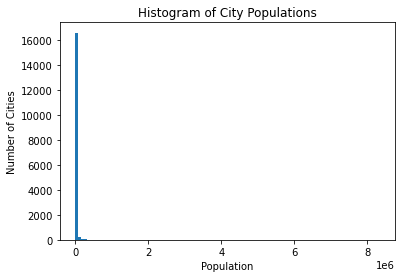

In [35]:
plt.title('Histogram of City Populations')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(all_data_w_p.pop_2019, bins=100)
plt.show()

In [36]:
ninetyfive = all_data_w_p.loc[ (all_data.pop_2019 <= all_data_w_p.pop_2019.quantile(.95)) ]

In [37]:
label( "Smallest City with 2019 population (lower 95%)", ninetyfive.pop_2019.min() )
label( "Largest City with 2019 population (lower 95%)", ninetyfive.pop_2019.max() )
label( "Cities with 2019 population (lower 95%)", ninetyfive.pop_2019.count() )

Smallest City with 2019 population (lower 95%): 3
Largest City with 2019 population (lower 95%): 44303
Cities with 2019 population (lower 95%): 16116


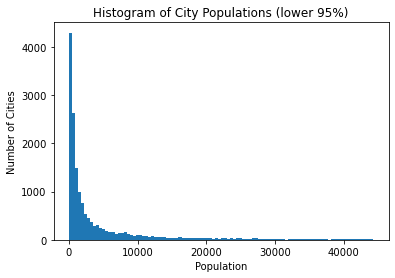

In [38]:
plt.title('Histogram of City Populations (lower 95%)')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(ninetyfive.pop_2019, bins=100)
plt.show()

### College Town Size Distribution
College Town Size Distribution
Examining the population size distribution of college towns we see that it is very heavily left-skewed. Additionally, there are a few outliers far to the right (very large populations).

Reducing our definition of College towns to not include those in the top five percentile by size, we reduce the number of samples from 717 to 681 and reduce the largest College Town population from 1,680,992 to 282,011 (which is in better keeping with the standard definition of a college town).

In [39]:
all_data_w_c = all_data.loc[ (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) ].copy()
label( "Smallest college town 2019 population", all_data_w_c.pop_2019.min() )
label( "Largest college town 2019 population", all_data_w_c.pop_2019.max() )

Smallest college town 2019 population: 672
Largest college town 2019 population: 1680992


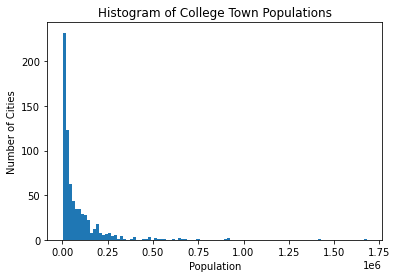

In [40]:
plt.title('Histogram of College Town Populations')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(all_data_w_c.pop_2019, bins=100)
plt.show()

In [41]:
ninetyfive_ct = all_data_w_c.loc[ (all_data.pop_2019 <= all_data_w_c.pop_2019.quantile(.95)) ]

In [42]:
label( "Smallest college town 2019 population (lower 95%)", ninetyfive_ct.pop_2019.min() )
label( "Largest college town 2019 population (lower 95%)", ninetyfive_ct.pop_2019.max() )
label( "College towns with 2019 population (lower 95%)", ninetyfive_ct.pop_2019.count() )

Smallest college town 2019 population (lower 95%): 672
Largest college town 2019 population (lower 95%): 282011
College towns with 2019 population (lower 95%): 681


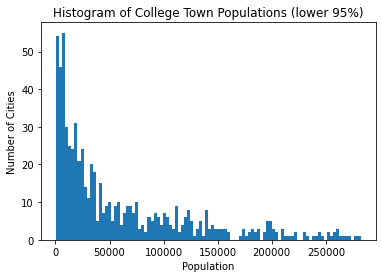

In [43]:
plt.title('Histogram of College Town Populations (lower 95%)')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(ninetyfive_ct.pop_2019, bins=100)
plt.show()

## Comparing similarly sized Cities

From here forward, when comparing college town populations to the larger population data I will limit the dataset to cities with a known population of less than 285,000 so as to be comparing like samples.

In [44]:
data = all_data.loc[ (all_data.pop_2019 > 0) & (all_data.pop_2019 <= 285000) ]
data.to_csv('data.csv')

__Save Point 2__ (Run from here rather than re-process)

In [45]:
data = pd.read_csv("data.csv")

---

### Comparing populations of cities smaller than 285,000 in 2019 with College Towns of the same size
Of cities smaller than 285,000, those with colleges are, on average, larger (59367.92 mean compared to 8529.82). The Standard Deviation is also higher (64960.15 std compared to 22975.11).

In [46]:
data_ct = data.loc[(data.colleges_count > 0)]

label( "Population mean (cities < 285,000)", toTwo(data.pop_2019.mean()) )
label( "College Town Population mean (cities < 285,000)", toTwo(data_ct.pop_2019.mean()) )

label( "Population std (cities < 285,000)", toTwo(data.pop_2019.std()) )
label( "College Town Population std (cities < 285,000)", toTwo(data_ct.pop_2019.std()) )

Population mean (cities < 285,000): 8529.97
College Town Population mean (cities < 285,000): 59367.92
Population std (cities < 285,000): 22975.78
College Town Population std (cities < 285,000): 64960.15


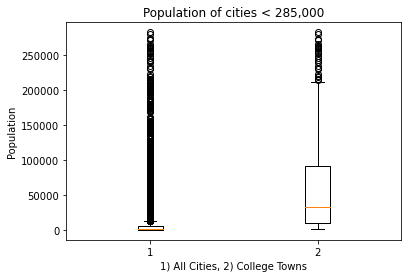

In [47]:
fig1, ax1 = plt.subplots()
plt.xlabel('1) All Cities, 2) College Towns')
plt.ylabel('Population')
ax1.set_title('Population of cities < 285,000')
ax1.boxplot([data.pop_2019, data.loc[(data.colleges_count > 0)]['pop_2019']], showfliers=True)
plt.show()

### Comparing  Population Mean by Year

In [48]:
index = data.loc[:,'pop_2010':'pop_2019'].columns.tolist()
columns = ['all_pop', 'ct_pop']
array = np.zeros( ( len(index), len(columns) ), dtype=float )
compare_mean = pd.DataFrame(array, columns=columns, index=index)

In [49]:
for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    compare_mean['all_pop'][column] = data[column].loc[ data[column] > 0 ].mean()

for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    compare_mean['ct_pop'][column] = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].mean()

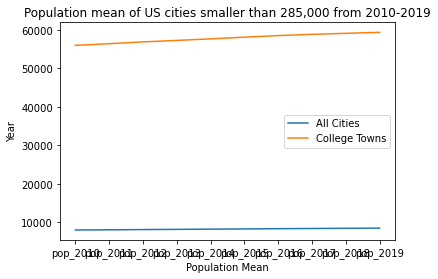

In [50]:
v1 = compare_mean.all_pop
v2 = compare_mean.ct_pop
years = compare_mean.index.tolist()

plt.title('Population mean of US cities smaller than 285,000 from 2010-2019')
plt.xlabel('Population Mean')
plt.ylabel('Year')
plt.plot(years, v1, label="All Cities")
plt.plot(years, v2, label="College Towns")
plt.legend()

plt.show()

In [51]:
# mean population each year of all cities < 285,000
for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    value = data[column].loc[ data[column] > 0 ].mean()
    label( remove_all("pop_", column) + " population mean (cities < 285,000)", toTwo( value ) )

2010 population mean (cities < 285,000): 8041.87
2011 population mean (cities < 285,000): 8097.60
2012 population mean (cities < 285,000): 8153.65
2013 population mean (cities < 285,000): 8208.17
2014 population mean (cities < 285,000): 8266.40
2015 population mean (cities < 285,000): 8326.35
2016 population mean (cities < 285,000): 8385.35
2017 population mean (cities < 285,000): 8439.39
2018 population mean (cities < 285,000): 8485.97
2019 population mean (cities < 285,000): 8529.97


In [52]:
# mean population each year of College town
for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    value = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].mean()
    label( remove_all("pop_", column) + " population mean (college towns)", toTwo( value ) )

2010 population mean (college towns): 55987.55
2011 population mean (college towns): 56418.00
2012 population mean (college towns): 56880.91
2013 population mean (college towns): 57268.59
2014 population mean (college towns): 57672.18
2015 population mean (college towns): 58115.08
2016 population mean (college towns): 58518.18
2017 population mean (college towns): 58847.95
2018 population mean (college towns): 59112.40
2019 population mean (college towns): 59367.92


### Comparing  Population Standard Deviation by Year

In [53]:
# mean population std year of all cities < 285,000
for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    value = data[column].loc[ data[column] > 0 ].std()
    label( remove_all("pop_", column) + " population std (cities < 285,000)", toTwo( value ) )

2010 population std (cities < 285,000): 21407.69
2011 population std (cities < 285,000): 21592.03
2012 population std (cities < 285,000): 21788.66
2013 population std (cities < 285,000): 21968.03
2014 population std (cities < 285,000): 22154.45
2015 population std (cities < 285,000): 22353.76
2016 population std (cities < 285,000): 22543.32
2017 population std (cities < 285,000): 22709.41
2018 population std (cities < 285,000): 22844.86
2019 population std (cities < 285,000): 22975.78


In [54]:
# population std each year of College town
for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    value = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].std()
    label( remove_all("pop_", column) + " population std (college towns)", toTwo( value ) )

2010 population std (college towns): 60942.83
2011 population std (college towns): 61416.55
2012 population std (college towns): 61945.61
2013 population std (college towns): 62381.36
2014 population std (college towns): 62842.69
2015 population std (college towns): 63363.24
2016 population std (college towns): 63872.40
2017 population std (college towns): 64297.84
2018 population std (college towns): 64644.40
2019 population std (college towns): 64960.15


### Compring Sale Price Mean by Month

In [55]:
index = data.loc[:,'1996-01-31':'2020-08-31'].columns.tolist()
columns = ['all_pop', 'ct_pop']
array = np.zeros( ( len(index), len(columns) ), dtype=float )
compare_mean = pd.DataFrame(array, columns=columns, index=index)

In [56]:
for column in data.loc[:,'1996-01-31':'2020-08-31'].columns.tolist():
    compare_mean['all_pop'][column] = data[column].loc[ data[column] > 0 ].mean()

for column in data.loc[:,'1996-01-31':'2020-08-31'].columns.tolist():
    compare_mean['ct_pop'][column] = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].mean()

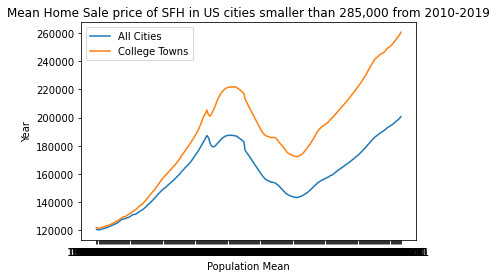

In [57]:
v1 = compare_mean.all_pop
v2 = compare_mean.ct_pop
years = compare_mean.index.tolist()

plt.title('Mean Home Sale price of SFH in US cities smaller than 285,000 from 2010-2019')
plt.xlabel('Population Mean')
plt.ylabel('Year')
plt.plot(years, v1, label="All Cities")
plt.plot(years, v2, label="College Towns")
plt.legend()

plt.show()

In [58]:
# mean sale price each month of all cities < 285,000
for column in data.loc[:,'1996-01-31':'2020-08-31'].columns.tolist():
    price_mean = data[column].loc[ data[column] > 0 ].mean()
    label( column + " price mean (cities < 285,000)", toTwo( price_mean ) )

1996-01-31 price mean (cities < 285,000): 120419.89
1996-02-29 price mean (cities < 285,000): 120194.37
1996-03-31 price mean (cities < 285,000): 120108.95
1996-04-30 price mean (cities < 285,000): 120252.14
1996-05-31 price mean (cities < 285,000): 120437.81
1996-06-30 price mean (cities < 285,000): 120605.77
1996-07-31 price mean (cities < 285,000): 120810.93
1996-08-31 price mean (cities < 285,000): 121015.92
1996-09-30 price mean (cities < 285,000): 121203.93
1996-10-31 price mean (cities < 285,000): 121461.38
1996-11-30 price mean (cities < 285,000): 121753.39
1996-12-31 price mean (cities < 285,000): 122013.46
1997-01-31 price mean (cities < 285,000): 122324.03
1997-02-28 price mean (cities < 285,000): 122581.65
1997-03-31 price mean (cities < 285,000): 122919.59
1997-04-30 price mean (cities < 285,000): 123249.94
1997-05-31 price mean (cities < 285,000): 123612.59
1997-06-30 price mean (cities < 285,000): 124008.44
1997-07-31 price mean (cities < 285,000): 124403.98
1997-08-31 p

2020-06-30 price mean (cities < 285,000): 198885.92
2020-07-31 price mean (cities < 285,000): 199684.03
2020-08-31 price mean (cities < 285,000): 200719.98


In [59]:
# mean sale price each month of college towns
for column in data.loc[:,'1996-01-31':'2020-08-31'].columns.tolist():
    price_mean = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].mean()
    label( column + " price mean (cities < 285,000)", toTwo( price_mean ) )

1996-01-31 price mean (cities < 285,000): 121825.79
1996-02-29 price mean (cities < 285,000): 121469.71
1996-03-31 price mean (cities < 285,000): 121296.30
1996-04-30 price mean (cities < 285,000): 121425.27
1996-05-31 price mean (cities < 285,000): 121690.58
1996-06-30 price mean (cities < 285,000): 121870.57
1996-07-31 price mean (cities < 285,000): 122056.14
1996-08-31 price mean (cities < 285,000): 122291.93
1996-09-30 price mean (cities < 285,000): 122439.92
1996-10-31 price mean (cities < 285,000): 122746.79
1996-11-30 price mean (cities < 285,000): 122979.20
1996-12-31 price mean (cities < 285,000): 123365.99
1997-01-31 price mean (cities < 285,000): 123343.41
1997-02-28 price mean (cities < 285,000): 123816.71
1997-03-31 price mean (cities < 285,000): 124104.50
1997-04-30 price mean (cities < 285,000): 124515.59
1997-05-31 price mean (cities < 285,000): 124805.06
1997-06-30 price mean (cities < 285,000): 125209.00
1997-07-31 price mean (cities < 285,000): 125688.52
1997-08-31 p

2014-02-28 price mean (cities < 285,000): 192452.55
2014-03-31 price mean (cities < 285,000): 193173.16
2014-04-30 price mean (cities < 285,000): 193768.74
2014-05-31 price mean (cities < 285,000): 194149.36
2014-06-30 price mean (cities < 285,000): 194755.30
2014-07-31 price mean (cities < 285,000): 195318.27
2014-08-31 price mean (cities < 285,000): 195836.51
2014-09-30 price mean (cities < 285,000): 196369.47
2014-10-31 price mean (cities < 285,000): 196947.93
2014-11-30 price mean (cities < 285,000): 198073.33
2014-12-31 price mean (cities < 285,000): 198832.91
2015-01-31 price mean (cities < 285,000): 199481.47
2015-02-28 price mean (cities < 285,000): 200065.44
2015-03-31 price mean (cities < 285,000): 200999.50
2015-04-30 price mean (cities < 285,000): 201861.93
2015-05-31 price mean (cities < 285,000): 202755.68
2015-06-30 price mean (cities < 285,000): 203521.40
2015-07-31 price mean (cities < 285,000): 204318.95
2015-08-31 price mean (cities < 285,000): 205182.16
2015-09-30 p

---

## Questions for reviewers

I was surprised to see such a divergence in prices for college towns compared to the general population. The next step in exploring the data should be to try to separate the effect of city size on house sale price values. But I haven't figured out how to do that yet.

Another aspect I'd like to look at is to see if there has been a change in the pricing pattern in the last few months. College town economies are driven by students and with fewer students in town, that may translate to housing value changes. Again, I'm not sure how to go about calculating that. My first thought is rather than plotting mean price between the groups, I could plot the difference between the two means and see if there's a standard rate of widening, and if it changed this year.

I'm also unsure of how I should be grouping my comparison data. Up to this point, I have been comparing information about college towns to the entire population sample which also includes those college towns. Should I be doing that, or should I be comparing college towns to non-college towns?

---